<a href="https://colab.research.google.com/github/sana-k6/BankMarketingDataset/blob/main/BankMarketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importing necessary modules and reading the data

In [274]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score, accuracy_score,roc_auc_score,pairwise_distances,log_loss)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [ ]:
data = pd.read_csv('bank-full.csv', delimiter=";")

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
data["y"].value_counts()

,count
y,
no,39922
yes,5289


2. Exploratory Data Analysis (EDA) Let’s analyze distributions, correlations, and missing values.


In [ ]:
data['y'] = data['y'].map({'yes':1, 'no':0})

In [ ]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [ ]:
X = data.drop('y', axis=1)
y = data['y']

In [ ]:
numCol = X.select_dtypes(include=["int64", "float64"]).columns

In [ ]:
catCol = X.select_dtypes(include=["object"]).columns


In [ ]:
unknown_by_col = (data == "unknown").sum().sort_values(ascending=False)
unknown_by_col

,0
poutcome,36959
contact,13020
education,1857
job,288
age,0
default,0
balance,0
housing,0
marital,0
loan,0


In [ ]:
data_clean = data.replace("unknown", np.nan)
data_clean.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [ ]:
data_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,0
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,0
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,0


In [ ]:
numT = Pipeline(steps=[('imputer', SimpleImputer(strategy = 'mean')), ('scaler', StandardScaler())])
catT = Pipeline(steps=[('imputer', SimpleImputer(strategy = 'most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
ct = ColumnTransformer(transformers=[('num', numT, numCol), ('cat', catT, catCol)])

In [ ]:
data_clean['education'].unique()


array(['tertiary', 'secondary', nan, 'primary'], dtype=object)

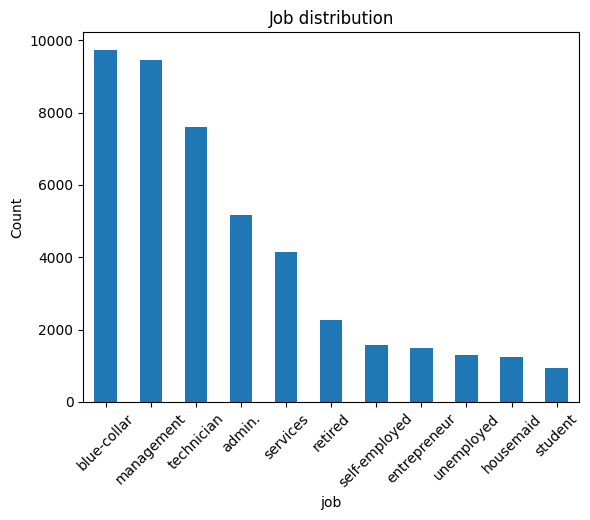

In [ ]:
data_clean["job"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

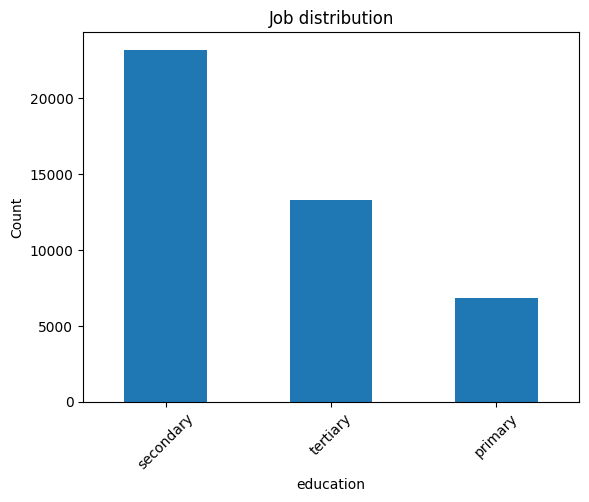

In [ ]:
data_clean["education"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

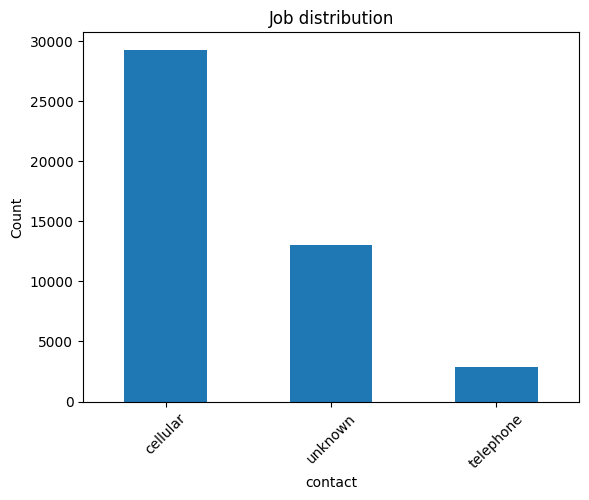

In [ ]:
data["contact"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

MODEL 1 : LOGISTIC REGRESSION without class weight=balanced

In [ ]:
model1 = Pipeline(steps=[('preprocessor', ct),('classifier', LogisticRegression(max_iter=1000))])

lets create the training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

lets fit the model to the training set

In [ ]:
model1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

the model will now predict the values of the test set

In [ ]:
y_pred = model1.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.63      0.33      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043

Accuracy: 0.8991485126617274
Precision: 0.6327272727272727
Recall: 0.32892249527410206
F1: 0.43283582089552236


array([[7783,  202],
       [ 710,  348]])

MODEL 2 : Logistic regression with class weight = balanced

In [ ]:
model2 = Pipeline(steps=[('preprocessor', ct),('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])

In [ ]:
model2.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y2_pred = model2.predict(X_test)

In [ ]:
print(classification_report(y_test, y2_pred))

print("Accuracy:", accuracy_score(y_test, y2_pred))
print("Precision:", precision_score(y_test, y2_pred))
print("Recall:", recall_score(y_test, y2_pred))
print("F1:", f1_score(y_test, y2_pred))

confusion_matrix(y_test, y2_pred)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.84      0.86      9043

Accuracy: 0.8446312064580338
Precision: 0.4162240463544182
Recall: 0.8147448015122873
F1: 0.5509747523170342


array([[6776, 1209],
       [ 196,  862]])

The recall is significantly higher which implies that the model is able to identify if the outcome is 1. The previous model fitted on an imbalanced dataset with more than 80% of the outcomes being 0 so it could blindly label all outcomes of the test as 0 and still have 80+ accuracy

Model 3 : Random Forest Classifier

In [238]:

rf_model = Pipeline([
    ('preprocessor', ct),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        criterion='gini',
        max_depth=7,
        max_features='sqrt',
        random_state=1
    ))
])

In [240]:
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(max_depth=7, n_estimators=500,
                                        random_state=1))])

In [241]:
y_pred = rf_model.predict(X_test)

In [242]:
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.79      0.15      0.26      1058

    accuracy                           0.90      9043
   macro avg       0.84      0.57      0.60      9043
weighted avg       0.89      0.90      0.86      9043

Accuracy: 0.8961627778392126
Precision: 0.7902439024390244
Recall: 0.15311909262759923
F1: 0.25653206650831356


array([[7942,   43],
       [ 896,  162]])

Let me use SMOTE to synthesize data points to balance the data set and see if the models perform better

In [262]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

smote_lr = Pipeline([
    ('preprocessor', ct),
    ('smote', SMOTE(sampling_strategy="minority",random_state=1)),
    ('classifier', LogisticRegression(max_iter=1000))
])


In [263]:
smote_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=1, sampling_strategy='minority')),
                ('classifier', LogisticRegression(max_iter=1000))])

In [264]:
y_pred = smote_lr.predict(X_test)

In [265]:
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.84      0.86      9043

Accuracy: 0.844741789229238
Precision: 0.4157740993184031
Recall: 0.8071833648393195
F1: 0.5488431876606684


array([[6785, 1200],
       [ 204,  854]])

did not make much of a difference in logistic regression, actually decreased

In [271]:
rf_model = Pipeline([
    ('preprocessor', ct),
    ('smote', SMOTE(sampling_strategy="minority",random_state=1)),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        criterion='gini',
        max_depth=7,
        max_features='sqrt',
        random_state=1))

])

In [272]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [273]:
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.80      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043

Accuracy: 0.8464005307973018
Precision: 0.41851304775972425
Recall: 0.8034026465028355
F1: 0.5503399158303658


array([[6804, 1181],
       [ 208,  850]])

using smote significantly increased the recall of the random forest classifier model

lets try using gridsearchcv to find the best model for random forest classifer

In [279]:
param_grid = {
    'classifier__n_estimators': [200, 500],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth' : [4,5,6,7,8],
    'classifier__criterion' :['gini', 'entropy']
}

model = Pipeline(steps=[('preprocessor', ct),('classifier', RandomForestClassifier())])



In [281]:
random_search = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=0
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot...
                                                                               Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                                             ('classifier',
                                              RandomForestClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [4, 5, 6, 7,
                                                                  8],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__n_estimators': [200, 500]},
                   random_state=0, scoring='f1')

In [282]:
print(random_search.best_params_)

{'classifier__n_estimators': 200, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8, 'classifier__criterion': 'gini'}


In [283]:
y_pred = random_search.predict(X_test)


In [284]:
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.79      0.16      0.27      1058

    accuracy                           0.90      9043
   macro avg       0.84      0.58      0.61      9043
weighted avg       0.89      0.90      0.87      9043

Accuracy: 0.8967156916952339
Precision: 0.7897196261682243
Recall: 0.15973534971644612
F1: 0.26572327044025157


array([[7940,   45],
       [ 889,  169]])

Hyperparameter tuning using RandomizedSearchCV produced only marginal improvements in the Random Forest classifier. Although the tuned model achieved high accuracy (89.7%) and precision (79.0%), its recall remained very low (16.0%), indicating that it failed to identify most customers who subscribed to the term deposit. This suggests that hyperparameter optimisation alone cannot overcome the effects of class imbalance. In comparison, the balanced Logistic Regression model achieved a substantially higher recall (81.5%) and F1-score (0.55), making it more suitable for identifying potential subscribers.